In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py

In [2]:
# #DATA - DISTRIBUTED IN Z
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_test1.nc') 
# parcel=xr.open_dataset(dir2+'cm1out_pdata_test1.nc') 

In [3]:
# #DATA - DISTRIBUTED IN P
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_test2.nc') 
# parcel=xr.open_dataset(dir2+'cm1out_pdata_test2.nc') 

In [7]:
# #DATA - DISTRIBUTED IN P
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') 
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc')  

In [4]:
# DATA - DISTRIBUTED IN P
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') 
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc')  

In [2]:
# # #DATA - DISTRIBUTED IN P
# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

In [5]:
# p_slice=slice(0,50_000_000)
z = parcel['z'].isel(time=0).data#[p_slice]

In [6]:
len(np.where(z<62)[0]) #total parcels in bottom layer

576003

Text(0.5, 1.0, 'Parcel Distribution by Height Level')

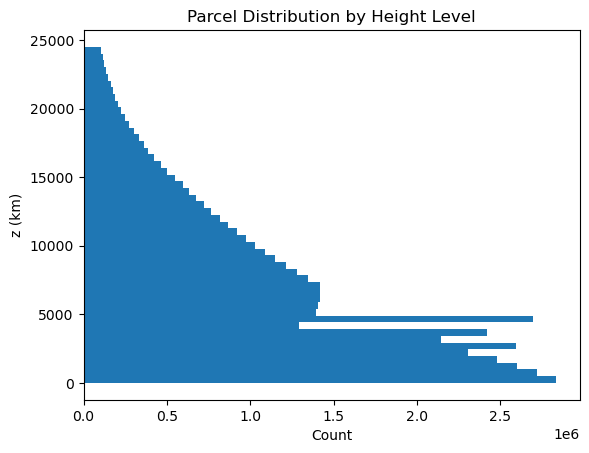

In [7]:
#PLOT OF LAGRANGIAN Z

counts, bin_edges, _ = plt.hist(z, bins=50, orientation='horizontal')
plt.ylabel('z (km)')
plt.xlabel('Count')
plt.title('Parcel Distribution by Height Level')
#max is 34 m, what?????

In [5]:
# plt.hist(zf[which_zh], weights=1/dz[which_zh], bins=50,orientation='horizontal');


In [6]:
# zf

In [97]:
# cond1=z<62
# np.where(cond1)[0].shape

In [98]:
# cond1=z>62
# cond2=z<155.89
# np.where(cond1&cond2)[0].shape

In [8]:
# counts

In [8]:
#LETS COUNT NUMBER IN EACH GRID BOX
#WHAT ARE THE MODEL Z-LEVELS
zh=data['zh'].values*1000; 
zf=data['zf'].values*1000; which_zh=np.clip(np.searchsorted(zf,z)-1,0,None)

which_zh

array([36, 61, 45, ..., 58, 55, 46])

In [9]:
print(zf)

np.searchsorted(zf,20001)-1

[    0.         50.        100.        150.        200.        250.
   300.        350.00003   400.        450.00003   500.        550.
   600.        650.00006   700.00006   750.00006   800.        850.
   900.00006   950.00006  1000.       1050.0001   1100.       1150.0001
  1200.       1250.       1300.0001   1350.       1400.0001   1450.
  1500.0001   1550.0001   1600.       1650.0001   1700.       1750.0001
  1800.0001   1850.0001   1900.0001   1950.       2000.       2050.0002
  2123.6843   2221.053    2342.1055   2486.842    2655.2634   2847.3684
  3063.158    3302.6318   3565.7898   3852.632    4163.158    4497.368
  4855.2637   5236.843    5642.1055   6071.053    6523.6846   7000.001
  7500.0005   8000.       8500.       9000.       9500.      10000.
 10500.001   11000.001   11500.001   12000.001   12500.001   13000.001
 13500.001   14000.001   14500.001   15000.001   15500.001   16000.
 16500.      17000.      17500.      18000.      18500.      19000.
 19500.      20000.    

85

[ 50.        50.        50.        50.        50.        50.
  50.00003   49.99997   50.00003   49.99997   50.        50.
  50.00006   50.        50.        49.99994   50.        50.00006
  50.        49.99994   50.000122  49.999878  50.000122  49.999878
  50.        50.000122  49.999878  50.000122  49.999878  50.000122
  50.        49.999878  50.000122  49.999878  50.000122  50.
  50.        50.        49.999878  50.        50.000244  73.68408
  97.36865  121.05249  144.73657  168.42139  192.10498  215.78955
 239.47388  263.15796  286.8423   310.52612  334.20996  357.8955
 381.5791   405.2627   428.94775  452.63135  476.3164   499.9995
 499.9995   500.       500.       500.       500.       500.00098
 500.       500.       500.       500.       500.       500.
 500.       500.       500.       500.       499.99902  500.
 500.       500.       500.       500.       500.       500.
 500.       500.00195  500.       500.       500.       500.
 500.       500.       500.       500.       

Text(0.5, 1.0, 'dz = zf[1:] - zf[:-1]')

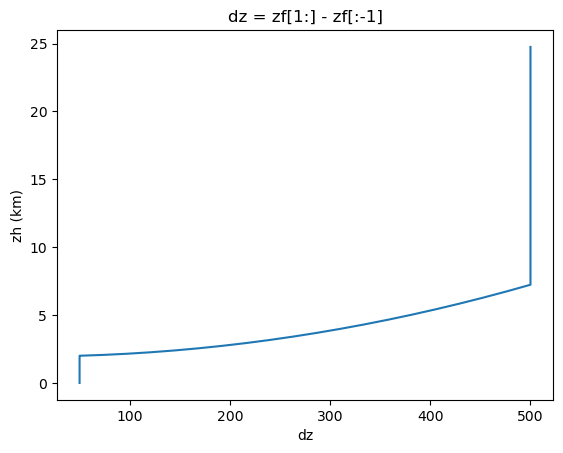

In [10]:
dz = zf[1:] - zf[:-1]
# dz=np.zeros([len(np.arange(len(zf)-1))])
# for k in range(len(dz)):
#     dz[k]=zf[k+1]-zf[k]
print(dz)
plt.plot(dz,data['zh'])
plt.ylabel('zh (km)');plt.xlabel('dz')
plt.title('dz = zf[1:] - zf[:-1]')

In [11]:
#LETS TRY MANUALLY BINNING
#MAKE PROFILE ARRAY
profile=np.zeros((len(zh),2))
profile[:,1]=zh

#BINNING
for z_ind in np.arange(len(data['zh'])):
    # count=len(np.where(which_zh==z_ind)[0])
    count = np.sum(which_zh == z_ind) #counts the number of parcels in z_ind

    profile[z_ind,0]=count
#dividing by dz
profile[:,0]/=dz  

Text(0.5, 1.0, 'dz = zf[1:] - zf[:-1]')

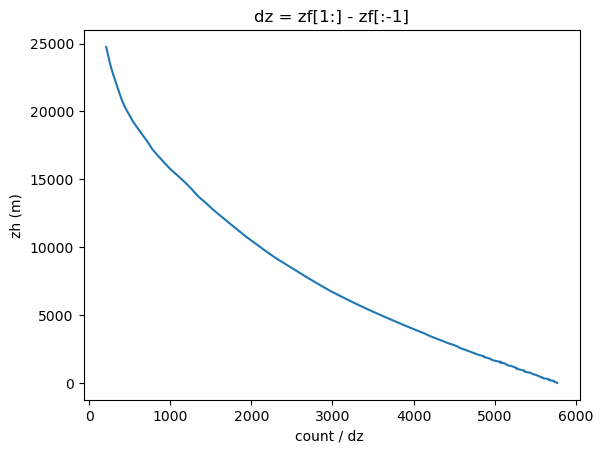

In [12]:
plt.plot(profile[:,0],profile[:,1])
plt.ylabel('zh (m)'); plt.xlabel('count / dz ')
plt.title('dz = zf[1:] - zf[:-1]')
# plt.xlim(left=0,right=60)

In [13]:
# rho=data['rho'].isel(time=0).mean(dim=('xh','yh')).data
# plt.plot(rho,data['zh'])
# plt.xlabel('rho')

In [14]:
# pltvar=profile[:,0]/rho
# plt.plot(pltvar,data['zh'])
# plt.xlabel('count/dz/rho')

In [15]:
#PLOTTING IN PRESSURE COORDINATE

Text(0, 0.5, 'zf (m)')

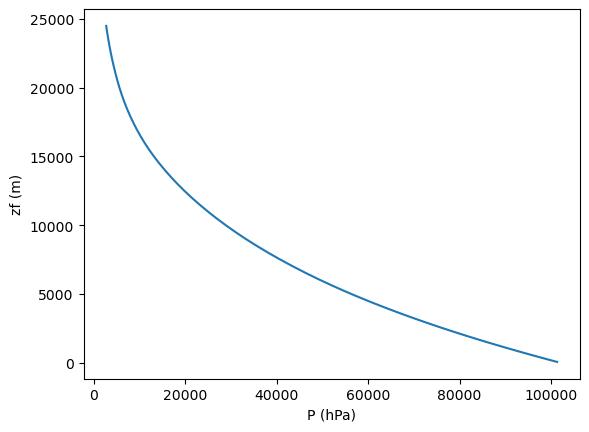

In [16]:
#PLOTTING P WITH HEIGHT
# P=data['prs'].isel(time=0,xh=0,yh=0).interp(zh=data['zf']).data/100
P=data['prs'].isel(time=0).mean(dim=('xh','yh')).interp(zh=data['zf']).data

plt.plot(P,data['zf']*1000)
plt.xlabel('P (hPa)');plt.ylabel('zf (m)')

In [17]:
P

array([        nan, 101334.625 , 100770.66  , 100208.86  ,  99649.31  ,
        99092.03  ,  98537.    ,  97984.266 ,  97433.87  ,  96885.74  ,
        96340.01  ,  95796.75  ,  95255.7   ,  94716.805 ,  94180.16  ,
        93645.75  ,  93113.66  ,  92583.95  ,  92056.53  ,  91531.41  ,
        91008.82  ,  90488.64  ,  89970.64  ,  89454.72  ,  88940.91  ,
        88429.41  ,  87920.29  ,  87413.44  ,  86908.72  ,  86406.22  ,
        85906.12  ,  85408.375 ,  84912.85  ,  84419.56  ,  83928.59  ,
        83439.93  ,  82953.53  ,  82469.445 ,  81987.82  ,  81508.69  ,
        81032.    ,  80557.88  ,  79863.57  ,  78953.35  ,  77833.56  ,
        76512.055 ,  74997.22  ,  73298.21  ,  71426.71  ,  69395.75  ,
        67217.22  ,  64904.89  ,  62475.34  ,  59945.51  ,  57332.81  ,
        54652.38  ,  51920.766 ,  49157.793 ,  46377.938 ,  43591.445 ,
        40807.97  ,  38161.594 ,  35650.312 ,  33272.984 ,  31023.596 ,
        28893.02  ,  26875.293 ,  24967.74  ,  23165.525 ,  2146

In [18]:
# FIXING NANS AT THE BOUNDARIES

# USING EXTRAPOLATION
def extrapolate_boundaries(P, zh):
    P = P.copy()
    valid = np.where(np.isfinite(P))[0]
    if len(valid) < 2:
        return P  # or raise an error

    i0, i1 = valid[0], valid[-1]

    # Bottom
    if i0 > 0:
        slope = (P[i0+1] - P[i0]) / (zh[i0+1] - zh[i0])
        P[:i0] = P[i0] + slope * (zh[:i0] - zh[i0])

    # Top
    if i1 < len(P) - 1:
        slope = (P[i1] - P[i1-1]) / (zh[i1] - zh[i1-1])
        P[i1+1:] = P[i1] + slope * (zh[i1+1:] - zh[i1])

    return P
P = extrapolate_boundaries(P, zf)
P

# #USING CM1's PRINTED OUT VALUES 
# P[0]=101900.0/100
# P[-1]=5662.963/100

array([101898.59  , 101334.625 , 100770.66  , 100208.86  ,  99649.31  ,
        99092.03  ,  98537.    ,  97984.266 ,  97433.87  ,  96885.74  ,
        96340.01  ,  95796.75  ,  95255.7   ,  94716.805 ,  94180.16  ,
        93645.75  ,  93113.66  ,  92583.95  ,  92056.53  ,  91531.41  ,
        91008.82  ,  90488.64  ,  89970.64  ,  89454.72  ,  88940.91  ,
        88429.41  ,  87920.29  ,  87413.44  ,  86908.72  ,  86406.22  ,
        85906.12  ,  85408.375 ,  84912.85  ,  84419.56  ,  83928.59  ,
        83439.93  ,  82953.53  ,  82469.445 ,  81987.82  ,  81508.69  ,
        81032.    ,  80557.88  ,  79863.57  ,  78953.35  ,  77833.56  ,
        76512.055 ,  74997.22  ,  73298.21  ,  71426.71  ,  69395.75  ,
        67217.22  ,  64904.89  ,  62475.34  ,  59945.51  ,  57332.81  ,
        54652.38  ,  51920.766 ,  49157.793 ,  46377.938 ,  43591.445 ,
        40807.97  ,  38161.594 ,  35650.312 ,  33272.984 ,  31023.596 ,
        28893.02  ,  26875.293 ,  24967.74  ,  23165.525 ,  2146

In [17]:
# #INSTEAD PRINTED OUT WHOLE VECTOR IN CM1
# P=np.array([
#     101900.0, 101198.6, 100142.4, 98739.71, 97001.85, 94943.27, 92579.51, 89931.92,
#     87019.70, 83868.52, 80508.78, 76970.37, 73279.09, 69462.50, 65550.56, 61575.72,
#     57574.54, 53577.37, 49614.27, 45713.00, 41885.48, 38144.31, 34513.25, 31026.37,
#     27688.62, 24516.65, 21522.82, 18723.06, 16139.69, 13768.37, 11647.51, 9797.515,
#     8195.453, 6811.046, 5662.963
# ])
# P

array([101900.   , 101198.6  , 100142.4  ,  98739.71 ,  97001.85 ,
        94943.27 ,  92579.51 ,  89931.92 ,  87019.7  ,  83868.52 ,
        80508.78 ,  76970.37 ,  73279.09 ,  69462.5  ,  65550.56 ,
        61575.72 ,  57574.54 ,  53577.37 ,  49614.27 ,  45713.   ,
        41885.48 ,  38144.31 ,  34513.25 ,  31026.37 ,  27688.62 ,
        24516.65 ,  21522.82 ,  18723.06 ,  16139.69 ,  13768.37 ,
        11647.51 ,   9797.515,   8195.453,   6811.046,   5662.963])

[ -563.96875  -563.96875  -561.7969   -559.5469   -557.28125  -555.03125
  -552.7344   -550.39844  -548.125    -545.7344   -543.2578   -541.0469
  -538.89844  -536.64844  -534.40625  -532.09375  -529.7031   -527.4219
  -525.125    -522.58594  -520.1797   -518.       -515.9219   -513.8125
  -511.5      -509.1172   -506.85156  -504.71875  -502.5      -500.10156
  -497.7422   -495.52344  -493.28906  -490.96875  -488.66406  -486.39844
  -484.08594  -481.625    -479.1328   -476.6875   -474.1172   -694.3125
  -910.21875 -1119.7891  -1321.5078  -1514.8359  -1699.0078  -1871.5
 -2030.9609  -2178.5312  -2312.3281  -2429.5508  -2529.8281  -2612.7031
 -2680.4297  -2731.6133  -2762.9727  -2779.8555  -2786.4922  -2783.4766
 -2646.375   -2511.2812  -2377.3281  -2249.3887  -2130.5762  -2017.7266
 -1907.5527  -1802.2148  -1703.0664  -1605.3809  -1507.6074  -1413.8926
 -1326.5781  -1244.0527  -1160.7285  -1073.2559   -988.1758   -909.09863
  -833.1992   -765.4844   -707.16406  -649.52734  -590.0322   -

Text(0.5, 1.0, 'dP = P[1:] - P[:-1]')

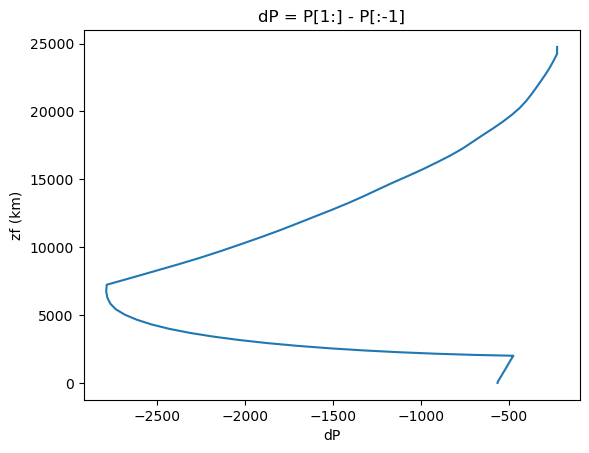

In [19]:
dP = P[1:] - P[:-1]
print(dP)

plt.plot(dP,zh)
plt.ylabel('zf (km)');plt.xlabel('dP')
plt.title('dP = P[1:] - P[:-1]')

In [20]:
#LETS COUNT NUMBER IN EACH GRID BOX
#WHAT ARE THE MODEL Z-LEVELS

In [21]:
#LETS TRY MANUALLY BINNING


#MAKE PROFILE ARRAY
profile=np.zeros((len(zh),2))
profile[:,1]=data['prs'].isel(time=0,xh=0,yh=0).data/100

#BINNING
for z_ind in np.arange(len(data['zh'])):
    count=len(np.where(which_zh==z_ind)[0])

    profile[z_ind,0]=+count
profile[:,0]/=dP

Text(0.5, 1.0, 'dP = P[1:] - P[:-1]')

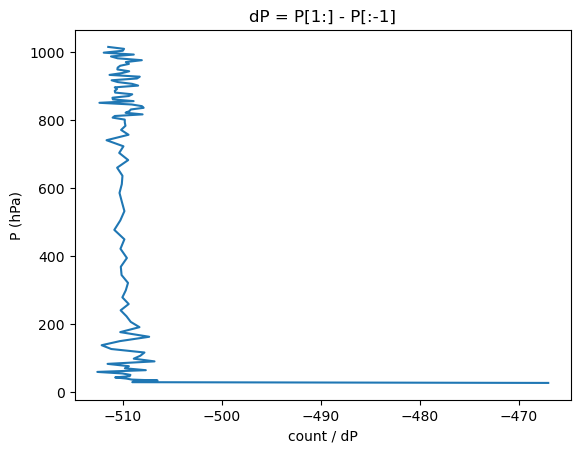

In [24]:
plt.plot(profile[:,0],profile[:,1])
plt.ylabel('P (hPa)'); plt.xlabel('count / dP')
plt.title('dP = P[1:] - P[:-1]')
# plt.xlim(left=-11*100,right=-10*100)

In [ ]:
# 1e5 kg in 1e4 km

In [21]:
1040*101_900

105976000

In [22]:
# hist_var=profile[:,0]
# plt.hist(hist_var,bins=5);